# **Loading some datasets. Only run this once.**

In [1]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data

--2026-04-22 22:14:40--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wine.data’

wine.data               [ <=>                ]  10.53K  --.-KB/s    in 0s      

2026-04-22 22:14:41 (190 MB/s) - ‘wine.data’ saved [10782]

--2026-04-22 22:14:41--  http://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘breast-cancer-wisconsin.data’

breast-cancer-wisco     [ <=>                ]  19.42K  --.-KB/s    in 0.06s   

2026-04-22 22:14:41 (312 

# **An Example of Categorical Naive Bayes**

This is a classification dataset for whether or not a tumor is benign or malignant. It uses categoric variables to describe the serverity of specific qualitative features of the tumor.

Train set size and number of dimensions (466, 9)
Test set size and number of dimensions (233, 9)



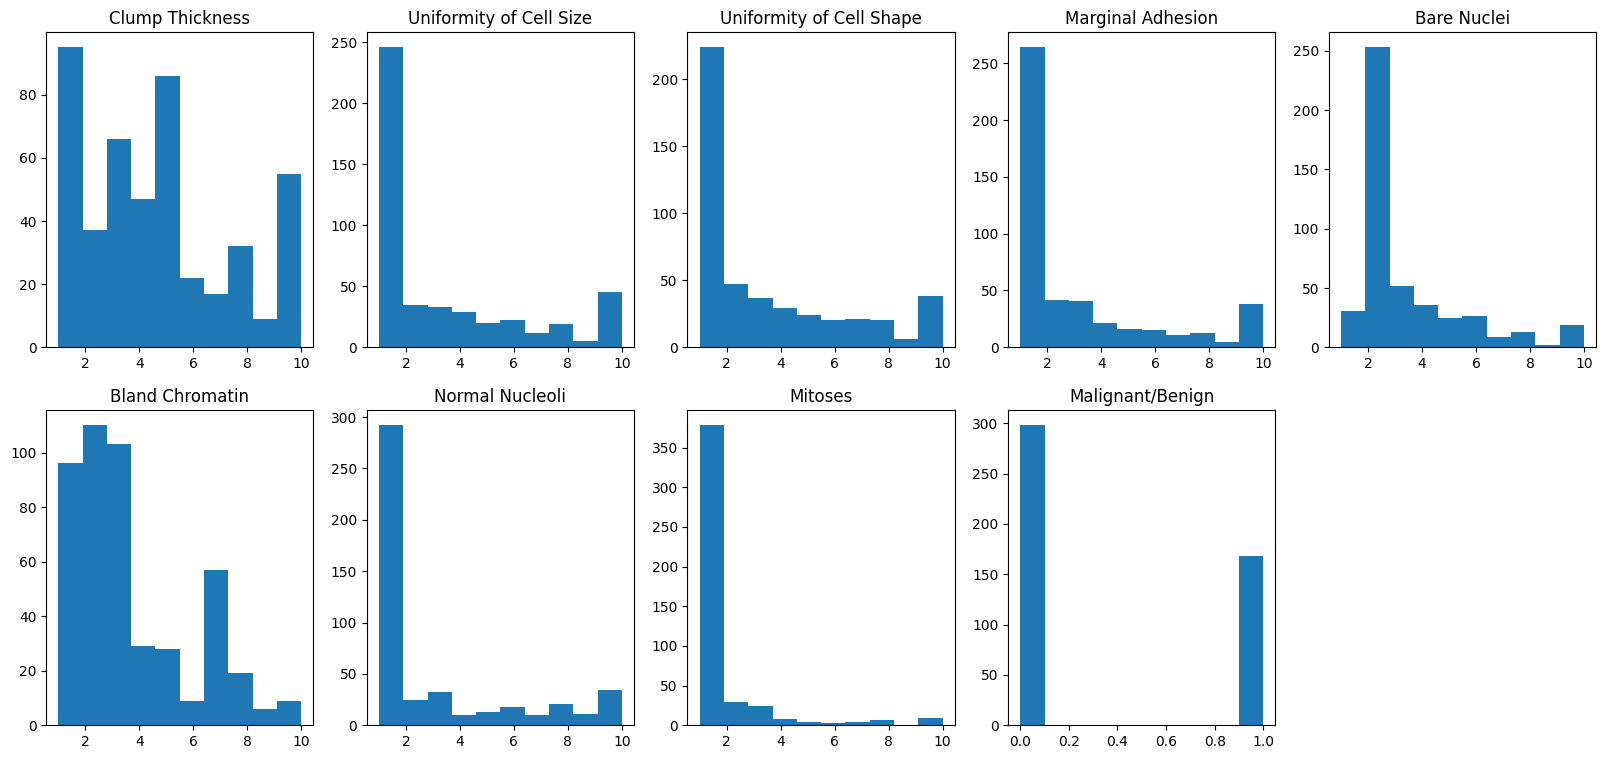

In [2]:
#Loading the data and looking at it a bit

import numpy as np
import matplotlib.pyplot as plt

cancer_data = np.loadtxt("breast-cancer-wisconsin.data",delimiter=",", usecols=[1,2,3,4,5,7,8,9,10])  #load data, skipping some columns that had missing data
cancer_data[cancer_data[:,-1]==2,-1] = 0  # output labels were 2/4 so mapping those to 0/1
cancer_data[cancer_data[:,-1]==4,-1] = 1
np.random.shuffle(cancer_data)            #shuffle!


train_cancer = cancer_data[0:len(cancer_data)//3*2] #split into train and test
test_cancer = cancer_data[len(cancer_data)//3*2:]
print("Train set size and number of dimensions", train_cancer.shape)
print("Test set size and number of dimensions", test_cancer.shape)
print()


#Plot histograms of our features / classes
column_names = ["Clump Thickness", "Uniformity of Cell Size", "Uniformity of Cell Shape", "Marginal Adhesion", "Bare Nuclei", "Bland Chromatin", "Normal Nucleoli", "Mitoses","Malignant/Benign"]

plt.figure(figsize=(20,9))
for i, name in enumerate(column_names):
  plt.subplot(2,5,i+1)
  plt.hist(train_cancer[:,i])
  plt.title(name)
plt.show()

In [ ]:
# Fit the prior distribution P(y)
prior_c = [np.sum(train_cancer[:,-1]==c)/len(train_cancer) for c in np.unique(train_cancer[:,-1])]  # number of times class c happens / total number of examples
print(prior_c)

[np.float64(0.6587982832618026), np.float64(0.34120171673819744)]


In [ ]:
#Fit Categoricals

num_classes = len(prior_c)
num_features = train_cancer.shape[1]-1

# Make a large matrix to hold our categoric distributions. There are 8 attributes, each attribute has 10 values, and there are 2 classes
#P(x_i | y)
dists = np.zeros( (train_cancer.shape[1]-1, 10, 2) )

for c in range(num_classes):
  train_where_c = train_cancer[train_cancer[:,-1] == c] # select the rows from train where the class is c

  for variable in range(num_features):
    # number of times vairables takes value val with class c / # number with class c
    dists[variable,:,c] = [np.sum(train_where_c[:,variable]==val+1) for val in range(10)]
    dists[variable,:,c] /= len(train_where_c)

print("P(x_1 | y=0) = ", dists[0,:,0])
print("P(x_1 | y=1) = ", dists[0,:,1])

P(x_1 | y=0) =  [0.31879195 0.09731544 0.20805369 0.14765101 0.19463087 0.03020134
 0.         0.0033557  0.         0.        ]
P(x_1 | y=1) =  [0.         0.02380952 0.02380952 0.04166667 0.16071429 0.07738095
 0.08333333 0.19642857 0.07142857 0.32142857]


In [ ]:
#Prediction

# Loop over all our test points
correct = 0
for example_row in test_cancer:
  log_p_of_c_given_x = np.log(prior_c)  # vector to store the log probability of each class given this example

  for c in range(num_classes): # for each class
    for i in range(num_features): # for each feature
      log_p_of_c_given_x[c] += np.log(dists[i, int(example_row[i]-1), c]+0.0000001)  # add the log probability of this feature occuring given this class
  #[ p(y=0|x) p(y=1|x)]
  label = np.argmax(log_p_of_c_given_x) # pick the class with the highest log prob
  if label == example_row[-1]:
    correct+=1

print("Accuracy: {:2.3}%".format(correct/len(test_cancer)*100))

Accuracy: 96.1%


In [ ]:
# What if we just choose the most frequent class seen in train
correct = 0
for example_row in test_cancer:
  log_p_of_c_given_x = np.log(prior_c)  # vector to store the log probability of each class given this example

  label = np.argmax(log_p_of_c_given_x) # pick the class with the highest log prob
  if label == example_row[-1]:
    correct+=1

print("Accuracy: {:2.3}%".format(correct/len(test_cancer)*100))

Accuracy: 68.7%


In [ ]:
# What if we just choose randomly
correct = 0
for example_row in test_cancer:
  label = np.random.choice([0,1], p=prior_c) # pick the class with the highest log prob
  if label == example_row[-1]:
    correct+=1

print("Accuracy: {:2.3}%".format(correct/len(test_cancer)*100))

Accuracy: 52.8%


# **An Example of Gaussian Naive Bayes**

This is a classification dataset to tell what cultivar of grape (out of 3) was used to make a specific wine. The features are continuous values based on chemical anylsis of the resulting wine

Train set size and number of dimensions (118, 14)
Test set size and number of dimensions (60, 14)



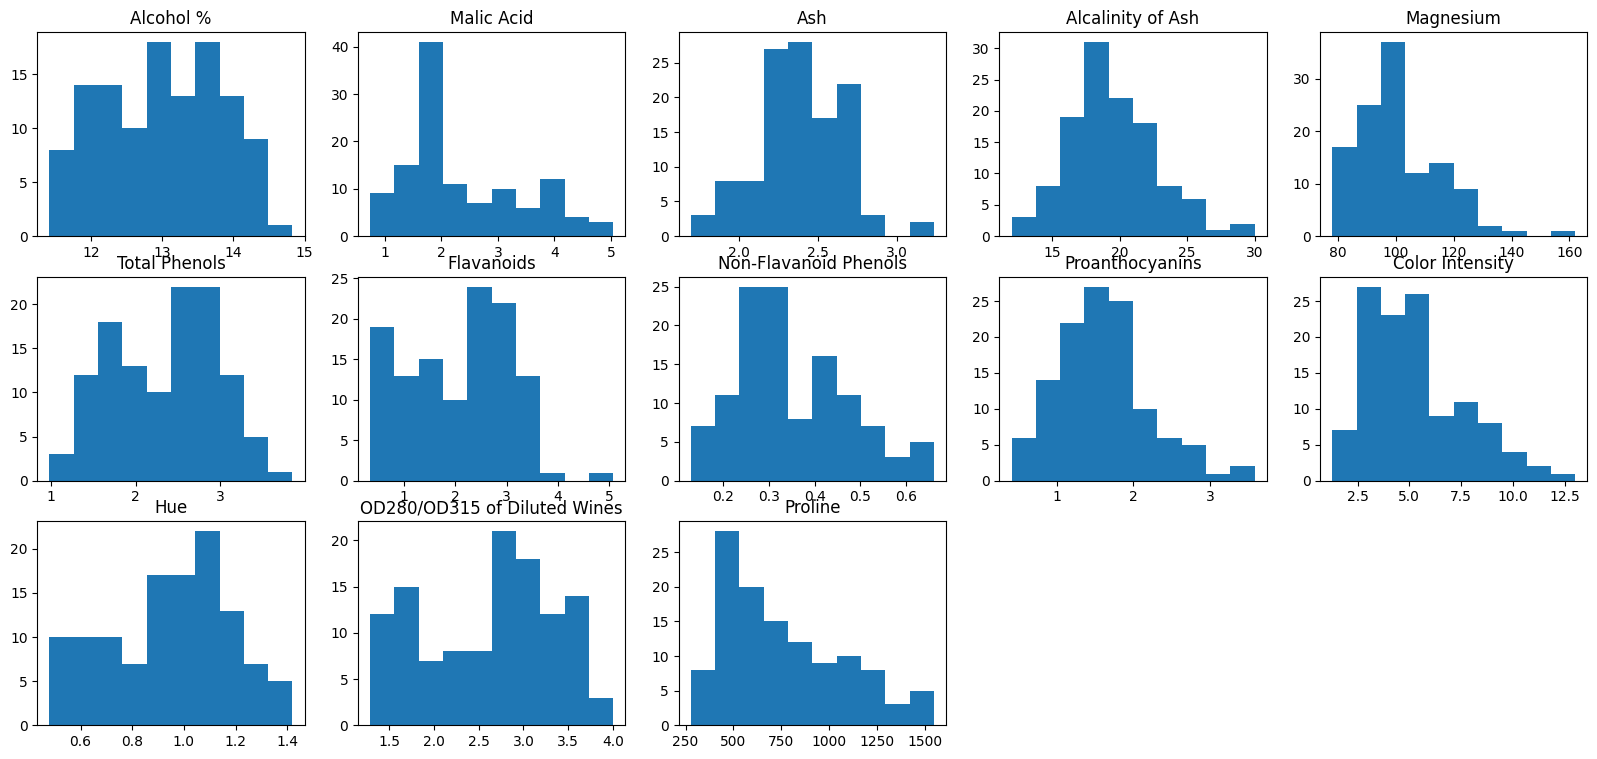

In [ ]:
#Loading the data and looking at it a bit

import numpy as np
import matplotlib.pyplot as plt

wine_data = np.loadtxt("wine.data",delimiter=",")
np.random.shuffle(wine_data)
train = wine_data[0:len(wine_data)//3*2]
test = wine_data[len(wine_data)//3*2:]
print("Train set size and number of dimensions", train.shape)
print("Test set size and number of dimensions", test.shape)
print()

column_names = ["Alcohol %", "Malic Acid", "Ash", "Alcalinity of Ash", "Magnesium", "Total Phenols", "Flavanoids", "Non-Flavanoid Phenols", "Proanthocyanins", "Color Intensity", "Hue", "OD280/OD315 of Diluted Wines", "Proline"]

plt.figure(figsize=(20,9))
for i, name in enumerate(column_names):
  plt.subplot(3,5,i+1)
  plt.hist(train[:,i+1])
  plt.title(name)
plt.show()



In [ ]:
# Fit the prior distribution P(y)
prior_c = [np.sum(train[:,0]==c)/len(train) for c in np.unique(train[:,0])]
print(prior_c)

[np.float64(0.3559322033898305), np.float64(0.3728813559322034), np.float64(0.2711864406779661)]


In [ ]:
#Fitting Gaussiasn to Each Input Attribute for each class

num_features = 13
num_classes = 3

means = np.zeros( (num_features, num_classes))  # place to store the mean for each feature for each class
stdevs = np.zeros( (num_features, num_classes)) # place to store the stdev for each feature for each class

for c in range(num_classes):

  train_where_c = train[train[:,0] == c+1] # select the rows from train where the class is c

  means[:,c] = np.mean(train_where_c[:,1:], axis=0) # compute the means of the features of these rows and store them
  stdevs[:,c] = np.std(train_where_c[:,1:], axis=0) # compute the stdev of the features of these rows and store them


  # Print things out for fun.
  print("For class {}".format(c))
  print("Name\tMean\tStdev")
  print("----------------------")
  for name, mean, stdev in zip(column_names[1:], means[:,c], stdevs[:,c]):
    print("{:5.5}\t{:2.4}\t{:2.4}".format(name, mean, stdev))
  print()

For class 0
Name	Mean	Stdev
----------------------
Malic	13.69	0.4653
Ash  	2.017	0.6755
Alcal	2.465	0.2311
Magne	17.2	2.454
Total	106.5	10.65
Flava	2.802	0.3001
Non-F	2.936	0.3697
Proan	0.2919	0.06991
Color	1.878	0.4281
Hue  	5.447	1.26
OD280	1.064	0.1069
Proli	3.187	0.3824

For class 1
Name	Mean	Stdev
----------------------
Malic	12.22	0.5332
Ash  	2.019	0.9683
Alcal	2.274	0.3133
Magne	20.22	3.157
Total	95.11	16.55
Flava	2.373	0.5922
Non-F	2.205	0.7733
Proan	0.3516	0.1298
Color	1.688	0.636
Hue  	3.251	0.9979
OD280	1.06	0.1981
Proli	2.782	0.5128

For class 2
Name	Mean	Stdev
----------------------
Malic	13.18	0.5375
Ash  	3.222	0.9886
Alcal	2.442	0.1889
Magne	21.28	2.291
Total	100.6	11.84
Flava	1.705	0.3826
Non-F	0.8434	0.3202
Proan	0.4213	0.1246
Color	1.182	0.4604
Hue  	7.692	2.329
OD280	0.6472	0.1018
Proli	1.684	0.2885



In [ ]:
#Prediction

#Helper function to compute the normal PDF value of a feature
def normpdf(x, mean, sd):
    var = sd**2
    denom = (2*np.pi*var)**.5
    num = np.exp(-(x-mean)**2/(2*var))
    return num/denom


# Loop over all our test points
correct = 0
for example_row in test:
  log_p_of_c_given_x = np.log(prior_c)  # vector to store the log probability of each class given this example

  for c in range(num_classes): # for each class
    for i in range(num_features): # for each feature
      log_p_of_c_given_x[c] += np.log(normpdf(example_row[i+1], means[i,c], stdevs[i,c]))  # add the log probability of this feature occuring given this class
  #log P(y=0|x) log(p(y=1|x) logP(y=2|x))
  label = np.argmax(log_p_of_c_given_x)+1 # pick the class with the highest log prob
  if label == example_row[0]:
    correct+=1

print("Accuracy: {:}%".format(correct/len(test)*100))



Accuracy: 98.33333333333333%


In [ ]:
# What if we just choose the most frequent class seen in train
correct = 0
for example_row in test:
  log_p_of_c_given_x = np.log(prior_c)  # vector to store the log probability of each class given this example

  label = np.argmax(log_p_of_c_given_x)+1 # pick the class with the highest log prob
  if label == example_row[0]:
    correct+=1

print("Accuracy: {:2.3}%".format(correct/len(test)*100))

Accuracy: 45.0%


In [ ]:
# What if we just choose randomly during inference
correct = 0
for example_row in test:
  logp_of_c = np.log(prior_c)  # vector to store the log probability of each class given this example

  label = np.random.choice([1,2,3], p=prior_c) # pick the class with the highest log prob
  if label == example_row[0]:
    correct+=1

print("Accuracy: {:2.3}%".format(correct/len(test)*100))

Accuracy: 33.3%
